<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Feature Maps and Encoding Choices

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `2.1`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We compare a naive angle assignment `theta = x` against a min-max scaling that maps the interval `[0, 10]` to `[0, pi]`. Using many more raw values makes the periodic wrap-around much easier to see.


In [2]:
def p1_from_ry(theta):
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    sv = Statevector.from_instruction(qc)
    return sv.probabilities_dict().get("1", 0.0)


def minmax_to_pi(x, x_min, x_max):
    return np.pi * (x - x_min) / (x_max - x_min)


raw_values = np.linspace(0.0, 10.0, 101)

p1_naive = [p1_from_ry(x) for x in raw_values]
p1_scaled = [p1_from_ry(minmax_to_pi(x, 0.0, 10.0)) for x in raw_values]

print("raw_values:", raw_values)
print("P(1) with theta = x:", np.round(p1_naive, 4))
print("P(1) with theta scaled from [0,10] to [0,pi]:", np.round(p1_scaled, 4))


raw_values: [ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10. ]
P(1) with theta = x: [0.000e+00 2.500e-03 1.000e-02 2.230e-02 3.950e-02 6.120e-02 8.730e-02
 1.176e-01 1.516e-01 1.892e-01 2.298e-01 2.732e-01 3.188e-01 3.663e-01
 4.150e-01 4.646e-01 5.146e-01 5.644e-01 6.136e-01 6.616e-01 7.081e-01
 7.524e-01 7.943e-01 8.331e-01 8.687e-01 9.006e-01 9.284e-01 9.520e-01
 9.711e-01 9.855e-01 9.950e-01 9.996e-01 9.991e-01 9.937e-01 9.834e-01
 9.682e-01 9.484e-01 9.241e-01 8.955e-01 8.630e-01 8.268e-01 7.874e-01
 7.451e-01 7.004e-01 6.537e

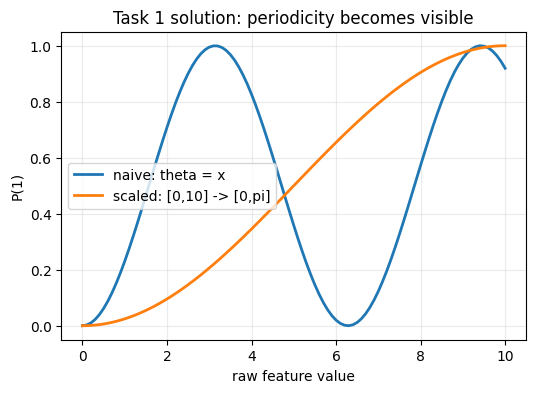

In [3]:
plt.figure(figsize=(6, 4))
plt.plot(raw_values, p1_naive, label="naive: theta = x", linewidth=2)
plt.plot(raw_values, p1_scaled, label="scaled: [0,10] -> [0,pi]", linewidth=2)
plt.xlabel("raw feature value")
plt.ylabel("P(1)")
plt.title("Task 1 solution: periodicity becomes visible")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


#### Task 1 conclusion

The scaled version is easier to interpret because the full raw interval is mapped into a controlled angle range and the resulting curve preserves a clear monotonic trend on that interval. In the naive version, the periodicity of the rotation makes the probability oscillate, so distinct raw values can produce similar outputs and the original ordering becomes harder to read. For classical preprocessing, this is a strong reason to scale features deliberately before angle encoding.


<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

We start from a length-3 vector, pad it to length 4, normalize it, and amplitude-encode it on two qubits.


In [4]:
raw_vector = np.array([1.0, 2.0, 3.0])
padded_vector = np.pad(raw_vector, (0, 1), mode="constant")
amp_vector = padded_vector / np.linalg.norm(padded_vector)

qc_amp = QuantumCircuit(2)
qc_amp.initialize(amp_vector, [0, 1])

sv_amp = Statevector.from_instruction(qc_amp)
probs_amp = sv_amp.probabilities_dict()

print("Padded vector:", padded_vector)
print("Normalized vector:", np.round(amp_vector, 4))
print("Amplitudes:", np.round(sv_amp.data, 4))
print("Probabilities:", {k: round(v, 4) for k, v in probs_amp.items()})


Padded vector: [1. 2. 3. 0.]
Normalized vector: [0.2673 0.5345 0.8018 0.    ]
Amplitudes: [0.2673+0.j 0.5345+0.j 0.8018+0.j 0.    +0.j]
Probabilities: {np.str_('00'): np.float64(0.0714), np.str_('01'): np.float64(0.2857), np.str_('10'): np.float64(0.6429)}


#### Task 2 explanation

The original vector has three nonzero entries, so the only zero introduced in the padded vector is the extra slot added to reach length 4. After normalization, that padded position still has zero amplitude, so the corresponding computational-basis state has zero probability. This makes it clear that the zero-probability outcome comes from padding, not from the original data values.


<a id="task3-solution"></a>

## Task 3 (coding): One complete solution

We repeat the previous padding example in PennyLane, using `qml.AmplitudeEmbedding` to handle padding and normalization directly.


In [5]:
import pennylane as qml

dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def amplitude_probs(x):
    qml.AmplitudeEmbedding(x, wires=[0, 1], pad_with=0.0, normalize=True)
    return qml.probs(wires=[0, 1])

raw_vector = np.array([1.0, 2.0, 3.0])
probs = amplitude_probs(raw_vector)

print("Raw vector:", raw_vector)
print("Probabilities:", np.round(probs, 4))


Raw vector: [1. 2. 3.]
Probabilities: [0.0714 0.2857 0.6429 0.    ]


#### Task 3 explanation

Because the input has length 3, `qml.AmplitudeEmbedding` pads it to length 4 by appending one zero before preparing the 2-qubit state. After normalization, the amplitude associated with that padded slot remains zero, so the corresponding computational-basis state has zero probability. Compared with the Qiskit version, the PennyLane workflow packages padding, normalization, and state preparation into a single high-level template call.


<a id="task4-solution"></a>

## Task 4 (design): Example answer

**Scenario A**
- Encoding choice: angle encoding.
- Estimated qubit count: about 8 qubits in the simple one-feature-per-qubit version.
- Preprocessing: scale each continuous feature to a controlled angle range such as $[0, \pi]$.
- Limitation: qubit count grows linearly with the number of features, and shallow angle encoding alone may not capture rich feature interactions.

**Scenario B**
- Encoding choice: basis encoding.
- Estimated qubit count: 32 qubits for 32-bit strings.
- Preprocessing: essentially none beyond making sure the data are represented as bits in a consistent order.
- Limitation: no compression in qubit count, but this is acceptable because the data are already discrete and basis encoding is natural.

**Scenario C**
- Encoding choice: mixed strategy, with angle encoding for the 6 continuous features and basis-style binary loading for the 2 flags if qubit budget allows; otherwise a fully angle-based representation is also defensible.
- Estimated qubit count: roughly 8 qubits in a simple interpretable layout.
- Preprocessing: scale the continuous features; keep the binary flags as `0/1` values or map them consistently to fixed rotations.
- Limitation: the mixed representation can be more awkward to design and reason about than a uniform encoding, but it respects the data types better.

A and C are both continuous-data problems, but they do not force the same decision. In A, the main pressure comes from the shallow-device budget and the match between 8 features and about 8 qubits, so simple angle encoding is natural. In C, interpretability and heterogeneous feature types matter more, so preserving the distinction between continuous and binary variables may be more valuable than using a single uniform encoding rule everywhere.
